# Model Performance and Assumption Checks

This notebook reviews saved model performance reports and runs sanity checks for the ICU LOS classification pipeline. It uses aggregate report artifacts plus the synthetic sample model, so it can run without restricted MIMIC-IV data.

In [1]:
from pathlib import Path
import os
import json
import sys

os.environ.setdefault('MPLCONFIGDIR', str(Path('/tmp') / 'icu_los_mpl_cache'))

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from src.data.splitting import assert_patient_split_integrity
from src.data.target import TARGET_COLUMN, TARGET_LABELS
from src.data.validation import assert_matching_feature_columns, assert_no_leakage_columns

reports_dir = REPO_ROOT / 'reports' / 'classification'
sample_path = REPO_ROOT / 'data' / 'sample' / 'icu_los_classification_sample.csv'
sample_model_path = REPO_ROOT / 'models' / 'icu_los_classifier_sample.joblib'

assert reports_dir.exists(), f'Missing reports directory: {reports_dir}'
assert sample_path.exists(), f'Missing sample data: {sample_path}'
assert sample_model_path.exists(), f'Missing sample model: {sample_model_path}'
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'legend.title_fontsize': 14,
    'figure.titlesize': 22,
})


## Performance Summary

In [2]:
comparison = pd.read_csv(reports_dir / 'model_comparison.csv')
test_comparison = (
    comparison[comparison['split'].eq('test')]
    .sort_values('macro_f1', ascending=False)
    .reset_index(drop=True)
)
display(test_comparison)

best_model = test_comparison.loc[0, 'model']
assert best_model == 'icu_los_classifier', f'Expected selected model to lead by macro F1, got {best_model}'

,model,split,macro_f1,weighted_f1,balanced_accuracy,roc_auc_ovr_macro,roc_auc_ovr_weighted
0,icu_los_classifier,test,0.590232,0.640299,0.616602,0.813992,0.807058
1,random_forest,test,0.579229,0.648666,0.565924,0.807460,0.800977
2,logistic_regression,test,0.560516,0.608480,0.604449,0.785262,0.775950
3,dummy_most_frequent,test,0.224589,0.342295,0.333333,0.500000,0.500000


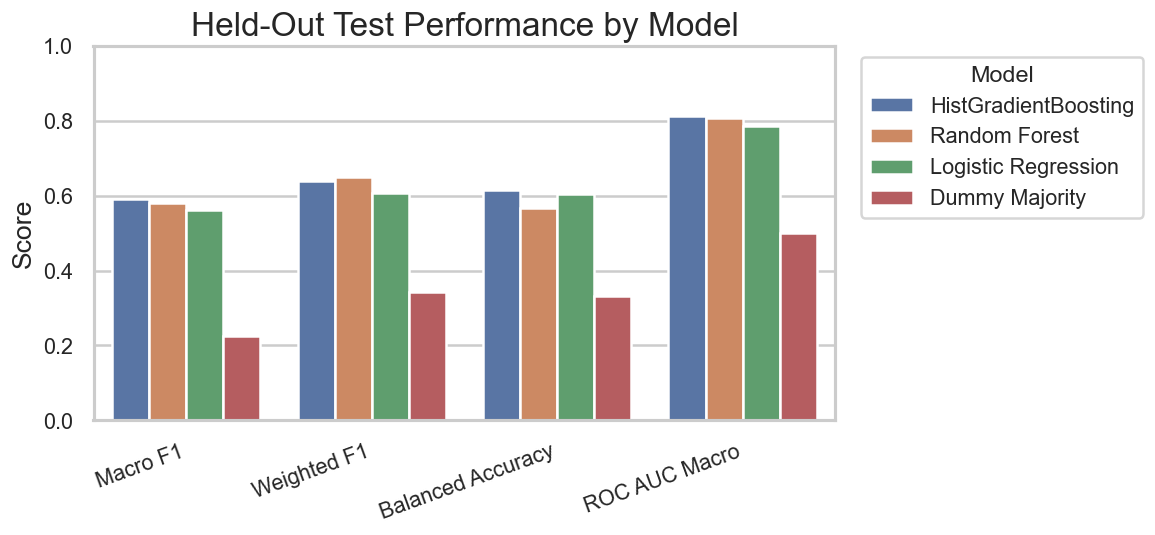

In [3]:
metric_labels = {
    'macro_f1': 'Macro F1',
    'weighted_f1': 'Weighted F1',
    'balanced_accuracy': 'Balanced Accuracy',
    'roc_auc_ovr_macro': 'ROC AUC Macro',
}
plot_df = test_comparison.melt(
    id_vars='model',
    value_vars=list(metric_labels.keys()),
    var_name='metric',
    value_name='score',
)
plot_df['metric'] = plot_df['metric'].map(metric_labels)
model_labels = {
    'icu_los_classifier': 'HistGradientBoosting',
    'random_forest': 'Random Forest',
    'logistic_regression': 'Logistic Regression',
    'dummy_most_frequent': 'Dummy Majority',
}
plot_df['model_label'] = plot_df['model'].map(model_labels)
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.barplot(data=plot_df, x='metric', y='score', hue='model_label', ax=ax)
ax.set_ylim(0, 1)
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_title('Held-Out Test Performance by Model')
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


In [4]:
per_class = pd.read_csv(reports_dir / 'icu_los_classifier' / 'test_per_class_metrics.csv')
confusion = pd.read_csv(reports_dir / 'icu_los_classifier' / 'test_confusion_matrix.csv', index_col=0)
display(per_class)
display(confusion)

assert set(per_class['class']) == {0, 1, 2}
assert confusion.shape == (3, 3)
assert int(per_class['support'].sum()) == int(confusion.to_numpy().sum())

,class,precision,recall,f1,support
0,0,0.792496,0.714483,0.751470,7243
1,1,0.549883,0.531450,0.540509,5310
2,2,0.396532,0.603873,0.478716,1704


,predicted_0,predicted_1,predicted_2
actual_0,5175,1754,314
actual_1,1236,2822,1252
actual_2,119,556,1029


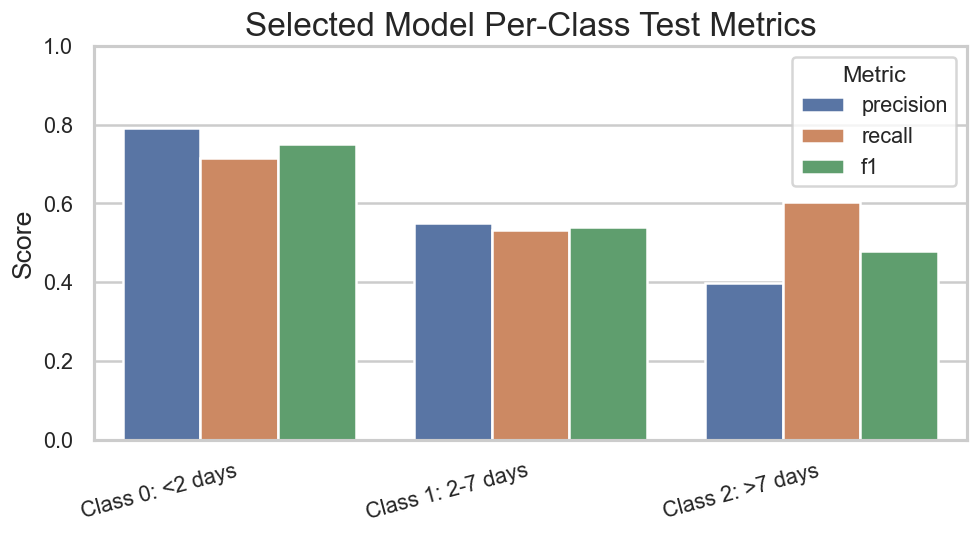

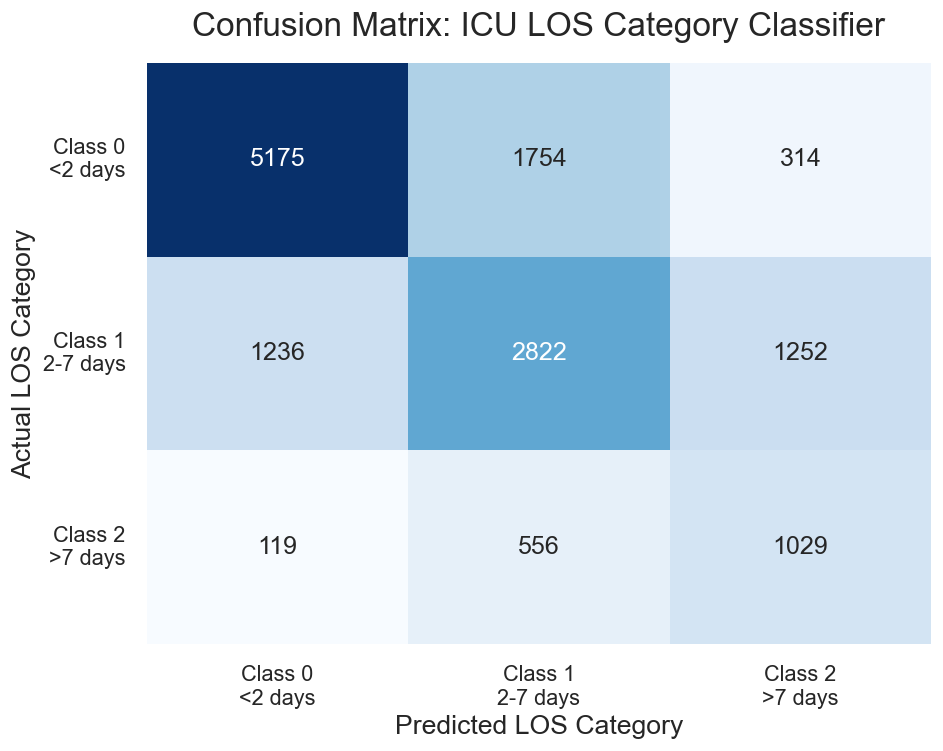

In [5]:
per_class_plot = per_class.melt(
    id_vars=['class', 'support'],
    value_vars=['precision', 'recall', 'f1'],
    var_name='metric',
    value_name='score',
)
per_class_plot['class_label'] = per_class_plot['class'].map({
    0: 'Class 0: <2 days',
    1: 'Class 1: 2-7 days',
    2: 'Class 2: >7 days',
})
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.barplot(data=per_class_plot, x='class_label', y='score', hue='metric', ax=ax)
ax.set_ylim(0, 1)
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_title('Selected Model Per-Class Test Metrics')
ax.legend(title='Metric')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

confusion_labels = ['Class 0\n<2 days', 'Class 1\n2-7 days', 'Class 2\n>7 days']
fig, ax = plt.subplots(figsize=(8.2, 6.6))
sns.heatmap(
    confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=ax,
    annot_kws={'size': 15},
)
ax.set_title('Confusion Matrix: ICU LOS Category Classifier', pad=16)
ax.set_xlabel('Predicted LOS Category')
ax.set_ylabel('Actual LOS Category')
ax.set_xticklabels(confusion_labels, rotation=0)
ax.set_yticklabels(confusion_labels, rotation=0)
plt.tight_layout()
plt.show()


## Split and Leakage Checks

In [6]:
split_df = pd.read_csv(reports_dir / 'patient_level_split.csv')
assert_patient_split_integrity(split_df)
assert set(split_df['split']) == {'train', 'val', 'test'}
assert set(split_df[TARGET_COLUMN].dropna().unique()).issubset({0, 1, 2})

split_summary = (
    split_df.groupby('split')
    .agg(rows=('stay_id', 'size'), subjects=('subject_id', 'nunique'))
    .sort_index()
)
display(split_summary)

,rows,subjects
split,,
test,14257,9804
train,66151,45747
val,14036,9804


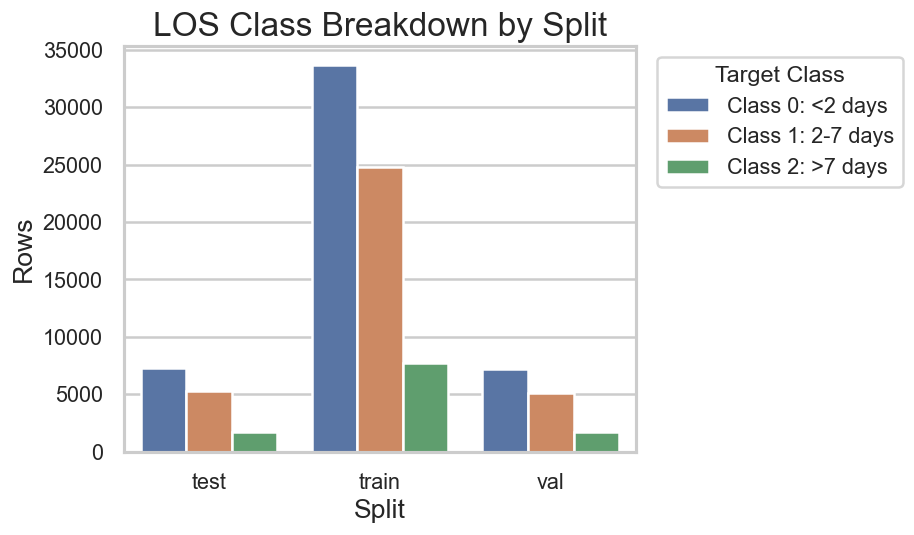

,split,los_category,rows,share
0,test,0,7243,0.508031
1,test,1,5310,0.372449
2,test,2,1704,0.119520
3,train,0,33644,0.508594
4,train,1,24773,0.374492
5,train,2,7734,0.116914
6,val,0,7220,0.514392
7,val,1,5083,0.362140
8,val,2,1733,0.123468


In [7]:
class_counts = (
    split_df.assign(class_label=split_df[TARGET_COLUMN].map({
        0: 'Class 0: <2 days',
        1: 'Class 1: 2-7 days',
        2: 'Class 2: >7 days',
    }))
    .groupby(['split', 'class_label'])
    .size()
    .reset_index(name='rows')
)
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=class_counts, x='split', y='rows', hue='class_label', ax=ax)
ax.set_title('LOS Class Breakdown by Split')
ax.set_xlabel('Split')
ax.set_ylabel('Rows')
ax.legend(title='Target Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

class_pct = split_df.groupby(['split', TARGET_COLUMN]).size().reset_index(name='rows')
class_pct['share'] = class_pct['rows'] / class_pct.groupby('split')['rows'].transform('sum')
display(class_pct)


In [8]:
artifact = joblib.load(sample_model_path)
model = artifact['model']
feature_columns = artifact['feature_columns']
numeric_columns = artifact['numeric_columns']
categorical_columns = artifact['categorical_columns']

assert artifact['target_column'] == TARGET_COLUMN
assert artifact['target_labels'] == TARGET_LABELS
assert_no_leakage_columns(feature_columns)
assert set(numeric_columns).isdisjoint(set(categorical_columns))
assert set(numeric_columns).union(categorical_columns) == set(feature_columns)
assert type(model.named_steps['model']).__name__ == 'HistGradientBoostingClassifier'

print(f'Checked {len(feature_columns)} feature columns for leakage-prone names.')
print(type(model.named_steps['model']).__name__)

Checked 19 feature columns for leakage-prone names.
HistGradientBoostingClassifier


## Saved Model Smoke Test

In [9]:
sample_df = pd.read_csv(sample_path)
missing = sorted(set(feature_columns).difference(sample_df.columns))
extra = sorted(set(sample_df.columns).difference(feature_columns + ['subject_id', 'hadm_id', 'stay_id', 'intime', TARGET_COLUMN]))
assert not missing, f'Sample data is missing model features: {missing}'
assert_matching_feature_columns(feature_columns, list(sample_df[feature_columns].columns))

pred = model.predict(sample_df[feature_columns])
proba = model.predict_proba(sample_df[feature_columns])
assert len(pred) == len(sample_df)
assert proba.shape == (len(sample_df), 3)
assert set(pred).issubset({0, 1, 2})

predictions = sample_df[['subject_id', 'stay_id', TARGET_COLUMN]].copy()
predictions['predicted_los_category'] = pred
for idx, label in enumerate(model.classes_):
    predictions[f'prob_class_{label}'] = proba[:, idx]
display(predictions.head(10))

,subject_id,stay_id,los_category,predicted_los_category,prob_class_0,prob_class_1,prob_class_2
0,1000,100000,1,2,0.050053,0.183030,0.766918
1,1001,100100,2,2,0.010621,0.363432,0.625946
2,1001,100101,2,2,0.010621,0.363432,0.625946
3,1002,100200,1,1,0.223925,0.663316,0.112759
4,1003,100300,1,0,0.563764,0.421744,0.014492
5,1004,100400,2,2,0.015493,0.115458,0.869049
6,1005,100500,1,2,0.013909,0.166428,0.819663
7,1006,100600,1,0,0.431106,0.247947,0.320947
8,1007,100700,2,2,0.014840,0.110593,0.874567
9,1008,100800,1,0,0.564158,0.422039,0.013803


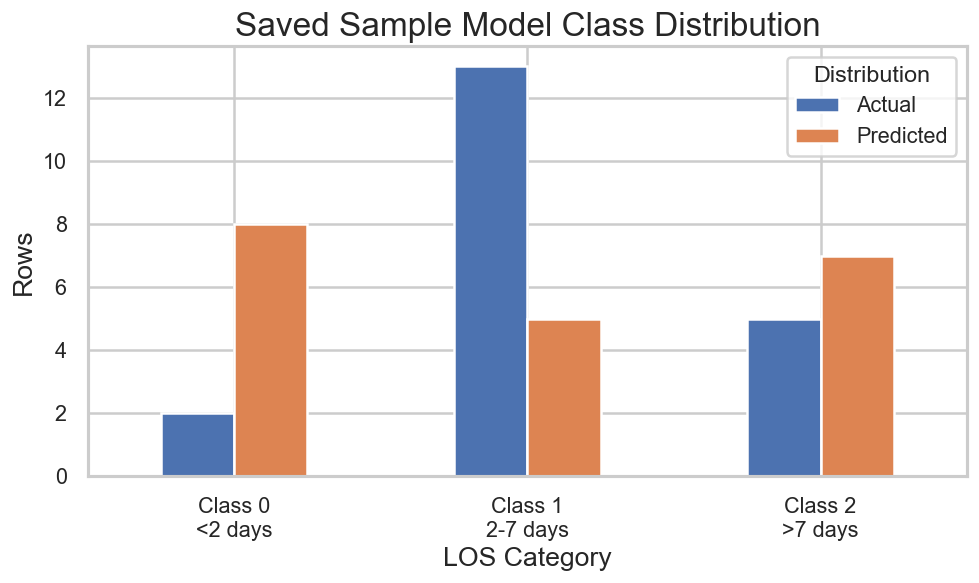

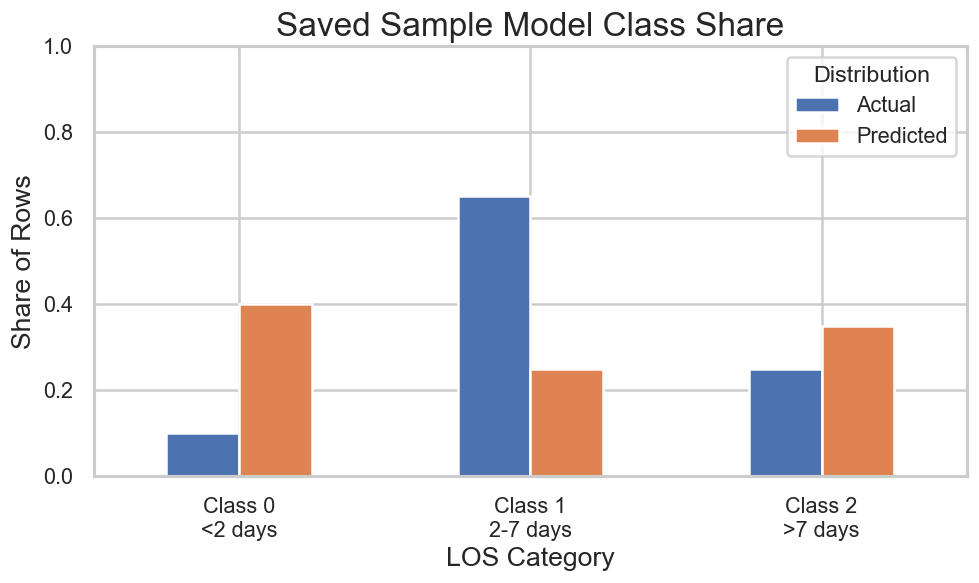

,Actual,Predicted
Class 0\n<2 days,2,8
Class 1\n2-7 days,13,5
Class 2\n>7 days,5,7


In [10]:
class_label_map = {
    0: 'Class 0\n<2 days',
    1: 'Class 1\n2-7 days',
    2: 'Class 2\n>7 days',
}
distribution_df = pd.concat(
    [
        predictions[TARGET_COLUMN].map(class_label_map).value_counts().rename('Actual'),
        predictions['predicted_los_category'].map(class_label_map).value_counts().rename('Predicted'),
    ],
    axis=1,
).reindex(class_label_map.values()).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
distribution_df.plot(kind='bar', ax=ax)
ax.set_title('Saved Sample Model Class Distribution')
ax.set_xlabel('LOS Category')
ax.set_ylabel('Rows')
ax.legend(title='Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

distribution_share_df = distribution_df.div(distribution_df.sum(axis=0), axis=1)
fig, ax = plt.subplots(figsize=(8.5, 5.2))
distribution_share_df.plot(kind='bar', ax=ax)
ax.set_title('Saved Sample Model Class Share')
ax.set_xlabel('LOS Category')
ax.set_ylabel('Share of Rows')
ax.set_ylim(0, 1)
ax.legend(title='Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(distribution_df)


## Check Summary

In [11]:
checks = pd.DataFrame(
    [
        {'check': 'patient split integrity', 'status': 'passed'},
        {'check': 'target labels limited to 0/1/2', 'status': 'passed'},
        {'check': 'feature leakage column scan', 'status': 'passed'},
        {'check': 'numeric/categorical feature partition', 'status': 'passed'},
        {'check': 'sample feature matrix matches saved model', 'status': 'passed'},
        {'check': 'saved model prediction/probability smoke test', 'status': 'passed'},
    ]
)
display(checks)

,check,status
0,patient split integrity,passed
1,target labels limited to 0/1/2,passed
2,feature leakage column scan,passed
3,numeric/categorical feature partition,passed
4,sample feature matrix matches saved model,passed
5,saved model prediction/probability smoke test,passed
